In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../results/shap', exist_ok=True)

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

feature_names = X_test.columns.tolist()

LABEL_MAP = {0: 'Benign', 1: 'DoS', 2: 'DDoS', 3: 'Mirai', 4: 'Spoofing'}

# Sample for fast models
X_shap_sample = X_test.sample(1000, random_state=42)
y_shap_sample = y_test.loc[X_shap_sample.index]

# Smaller sample for slow models (RF and ET)
X_shap_small = X_test.sample(200, random_state=42)
y_shap_small = y_test.loc[X_shap_small.index]

print(f"Full sample: {X_shap_sample.shape}")
print(f"Small sample (RF/ET): {X_shap_small.shape}")
print(f"Models available: {os.listdir('../results/models/')}")

Full sample: (1000, 30)
Small sample (RF/ET): (200, 30)
Models available: ['hier_stage1_DT.pkl', 'hier_stage1_ET.pkl', 'hier_stage2_HGB.pkl', 'hier_stage1_LGBM.pkl', 'hier_stage2_RF.pkl', 'hier_stage1_HGB.pkl', 'hier_stage2_LGBM.pkl', 'hier_stage2_ET.pkl', 'hier_stage2_XGB.pkl', 'hier_stage2_DT.pkl', 'hier_stage1_RF.pkl', 'hier_stage1_XGB.pkl']


In [4]:
def get_shap_importance(model, X_sample):
    """Compute mean absolute SHAP values per feature, handles all output formats."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    if isinstance(shap_values, np.ndarray):
        if shap_values.ndim == 3:
            sv_2d = shap_values[:, :, 0]
        else:
            sv_2d = shap_values
    elif isinstance(shap_values, list):
        sv_2d = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    
    importance = np.abs(sv_2d).mean(axis=0)
    return importance, sv_2d  # return both 1D importance AND 2D matrix

def plot_shap_bar(sv_2d, X_sample, title, save_path):
    """Plot and save a global SHAP bar chart — needs 2D matrix not 1D vector."""
    shap.summary_plot(
        sv_2d,              # 2D matrix (n_samples, n_features)
        X_sample,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("Helper functions ready")

Helper functions ready



Stage 1 SHAP — DT (1000 rows)...


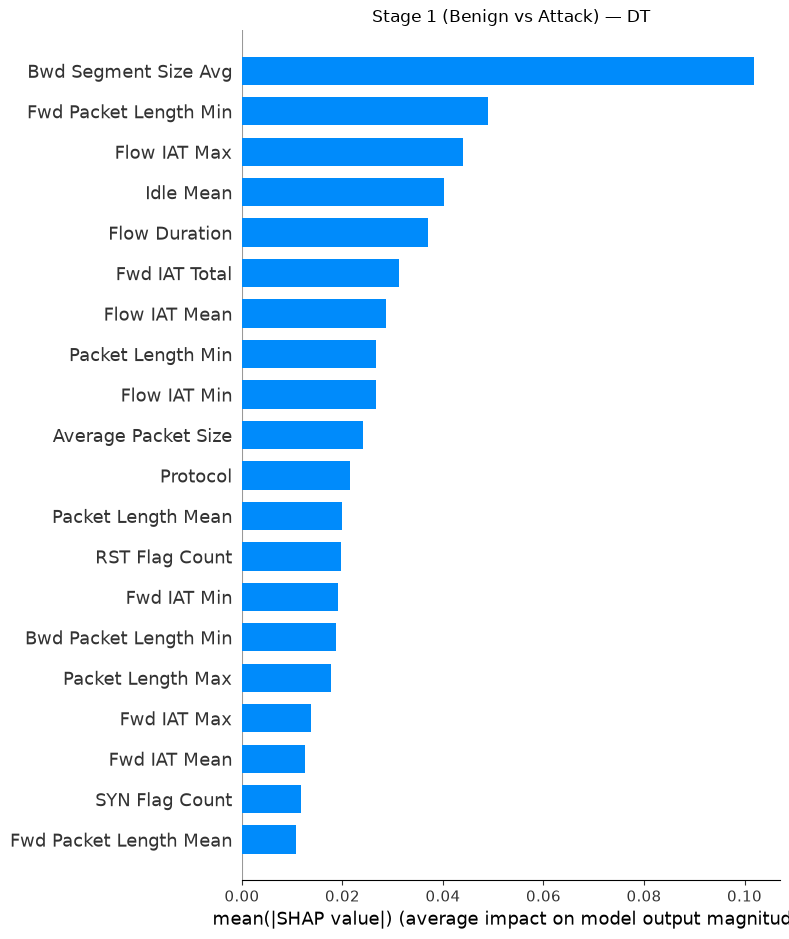

Saved: stage1_DT_global.png

Stage 1 SHAP — XGB (1000 rows)...


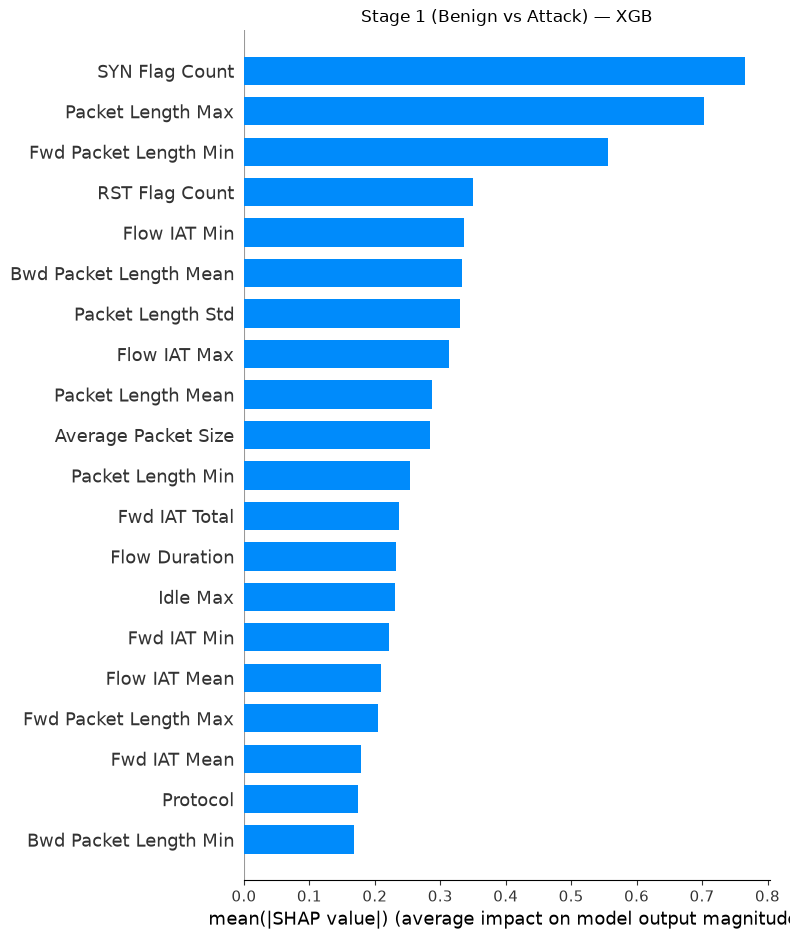

Saved: stage1_XGB_global.png

Stage 1 SHAP — LGBM (1000 rows)...


/Users/simrahruq/Documents/GitHub/flat-vs-hierarchical-ml-research/iot-research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


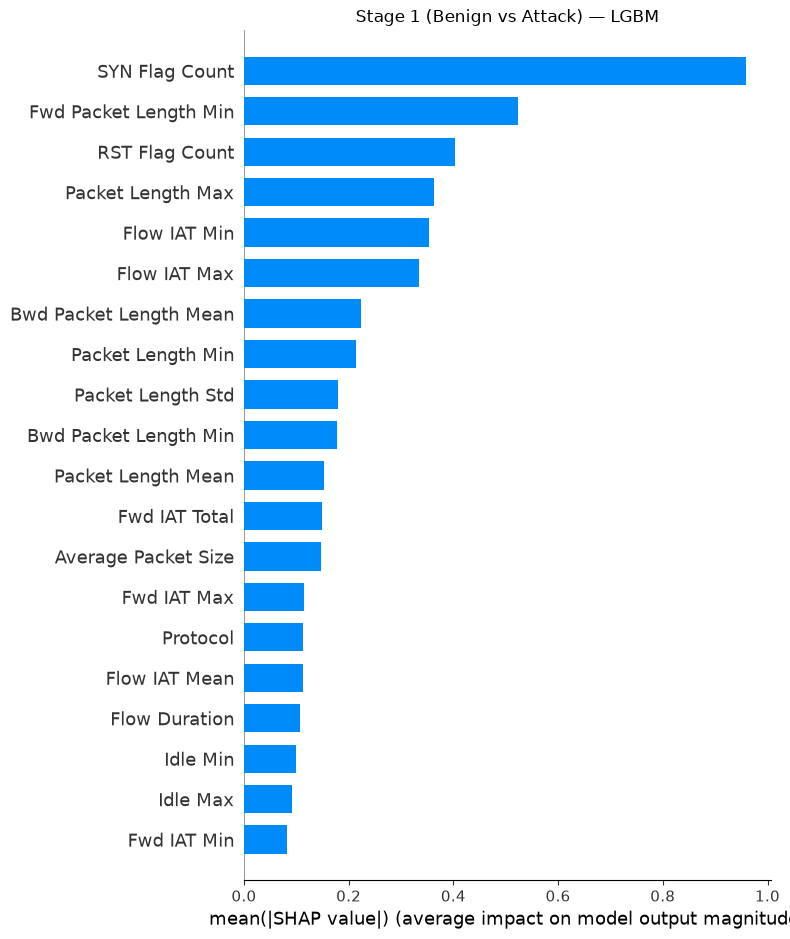

Saved: stage1_LGBM_global.png

Stage 1 SHAP — HGB (1000 rows)...


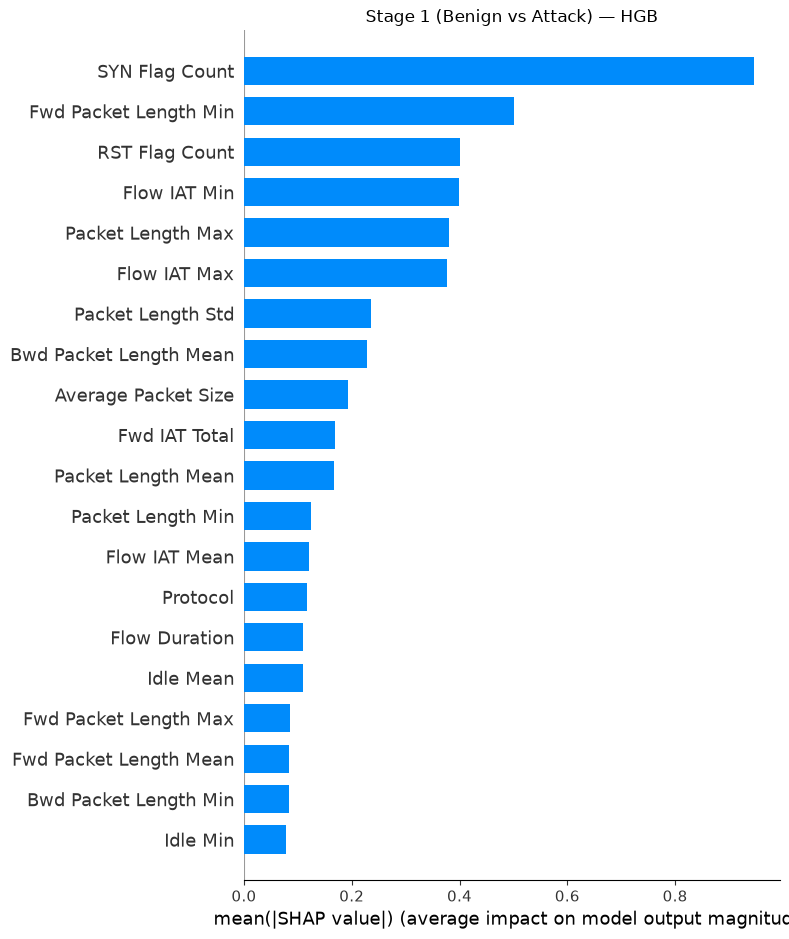

Saved: stage1_HGB_global.png

Stage 1 SHAP — ET (200 rows)...


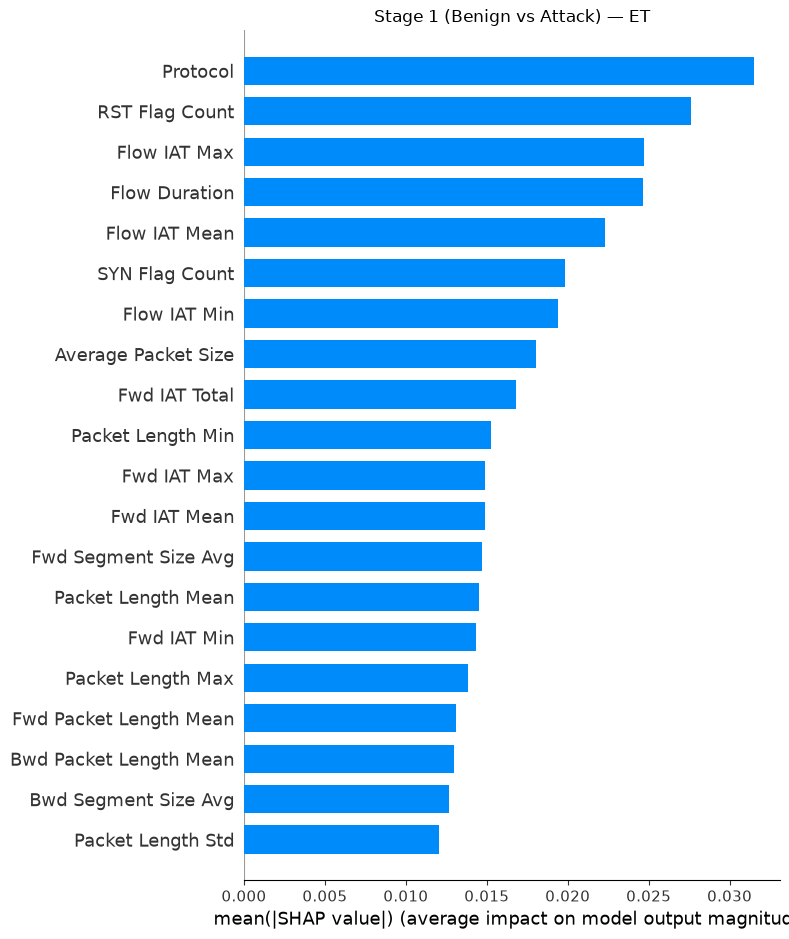

Saved: stage1_ET_global.png

Stage 1 SHAP — RF (200 rows)...


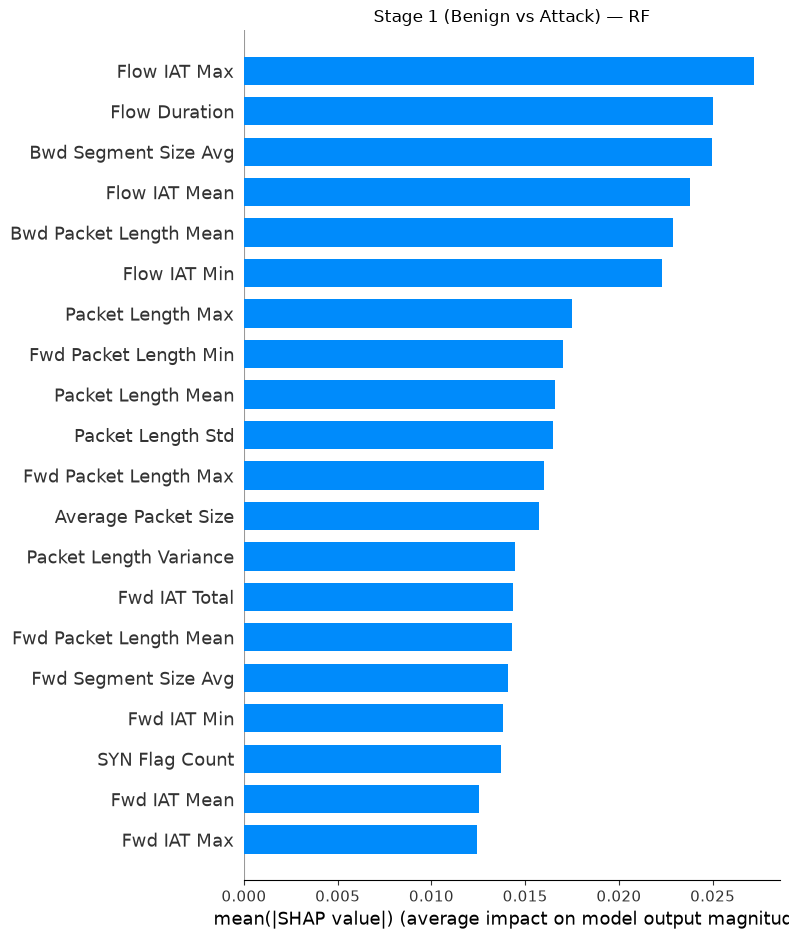

Saved: stage1_RF_global.png

All Stage 1 SHAP done


In [5]:
fast_models = ['DT', 'XGB', 'LGBM', 'HGB']
slow_models = ['ET', 'RF']

stage1_importance = {}
stage1_sv = {}  # also store the 2D matrices

# Fast models — 1000 rows
for model_name in fast_models:
    print(f"\nStage 1 SHAP — {model_name} (1000 rows)...")
    model = joblib.load(f'../results/models/hier_stage1_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_sample)
    stage1_importance[model_name] = importance
    stage1_sv[model_name] = sv_2d
    
    plot_shap_bar(
        sv_2d,
        X_shap_sample,
        f"Stage 1 (Benign vs Attack) — {model_name}",
        f"../results/shap/stage1_{model_name}_global.png"
    )
    print(f"Saved: stage1_{model_name}_global.png")

# Slow models — 200 rows
for model_name in slow_models:
    print(f"\nStage 1 SHAP — {model_name} (200 rows)...")
    model = joblib.load(f'../results/models/hier_stage1_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_small)
    stage1_importance[model_name] = importance
    stage1_sv[model_name] = sv_2d
    
    plot_shap_bar(
        sv_2d,
        X_shap_small,
        f"Stage 1 (Benign vs Attack) — {model_name}",
        f"../results/shap/stage1_{model_name}_global.png"
    )
    print(f"Saved: stage1_{model_name}_global.png")

print("\nAll Stage 1 SHAP done")

Stage 2 sample (fast models): (698, 30)
Stage 2 sample (slow models): (138, 30)

Stage 2 SHAP — DT...


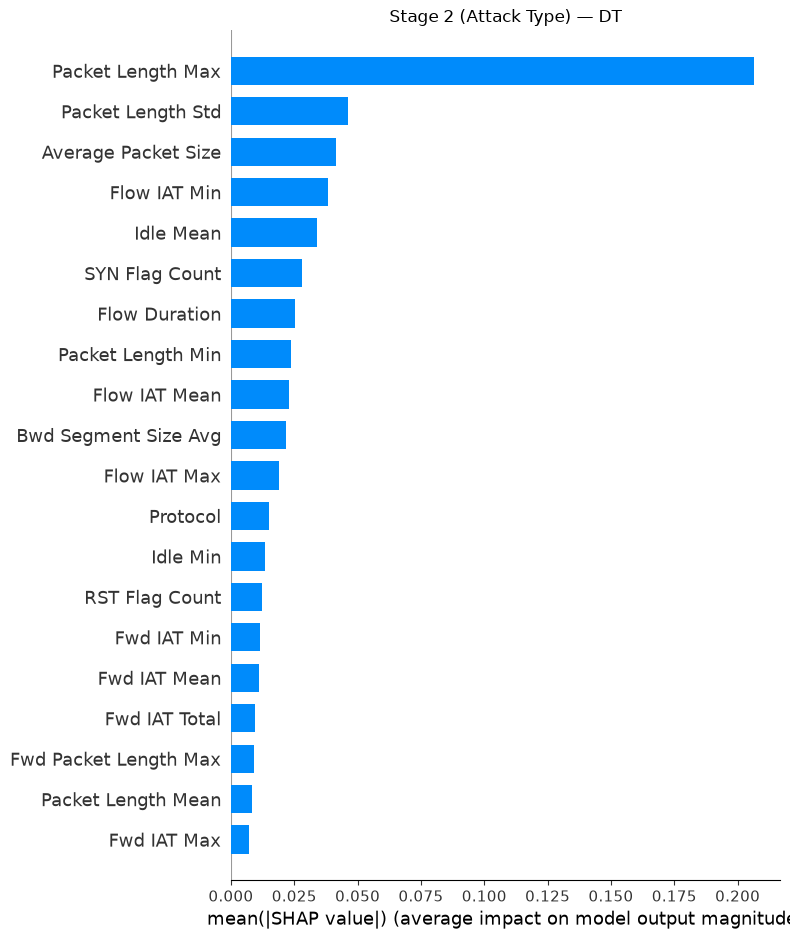

Saved: stage2_DT_global.png

Stage 2 SHAP — XGB...


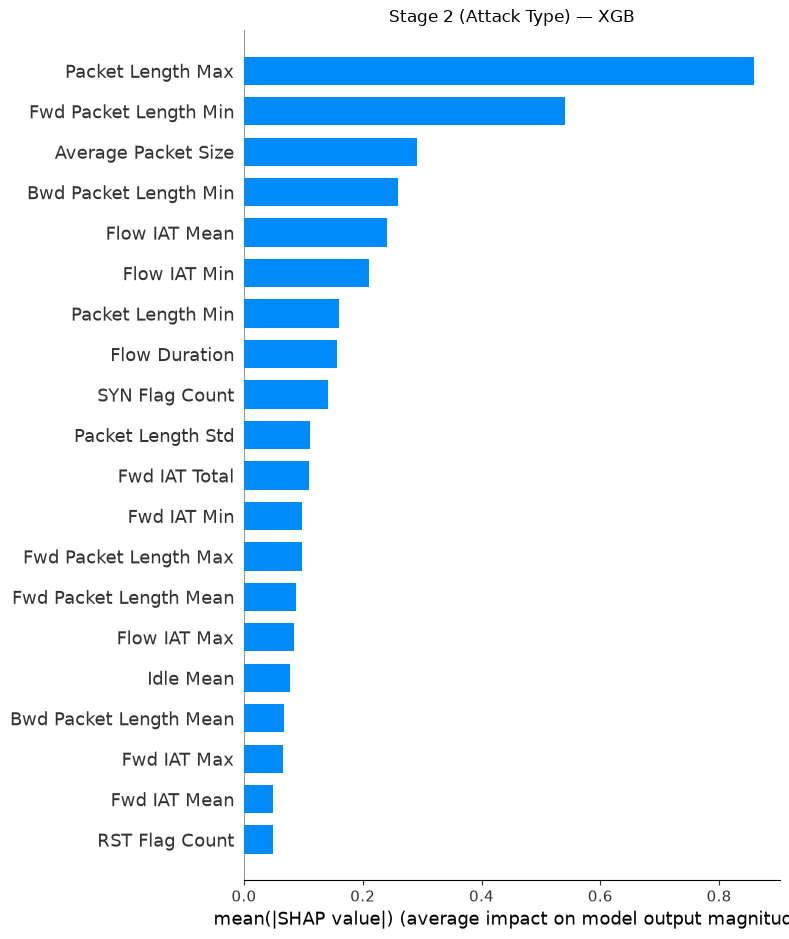

Saved: stage2_XGB_global.png

Stage 2 SHAP — LGBM...


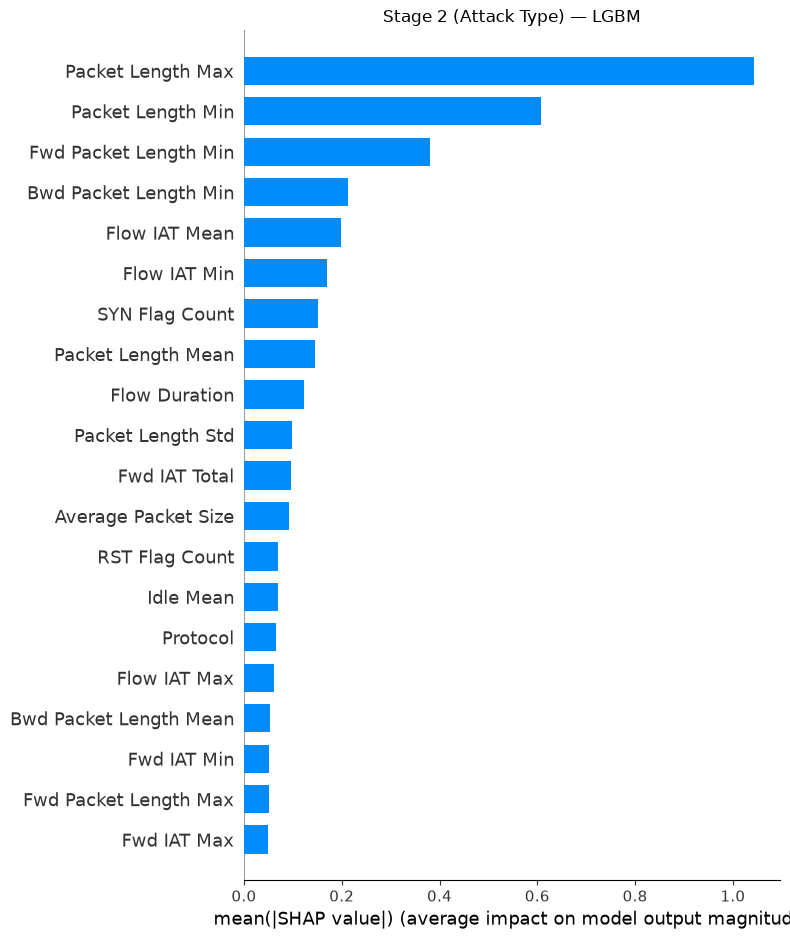

Saved: stage2_LGBM_global.png

Stage 2 SHAP — HGB...


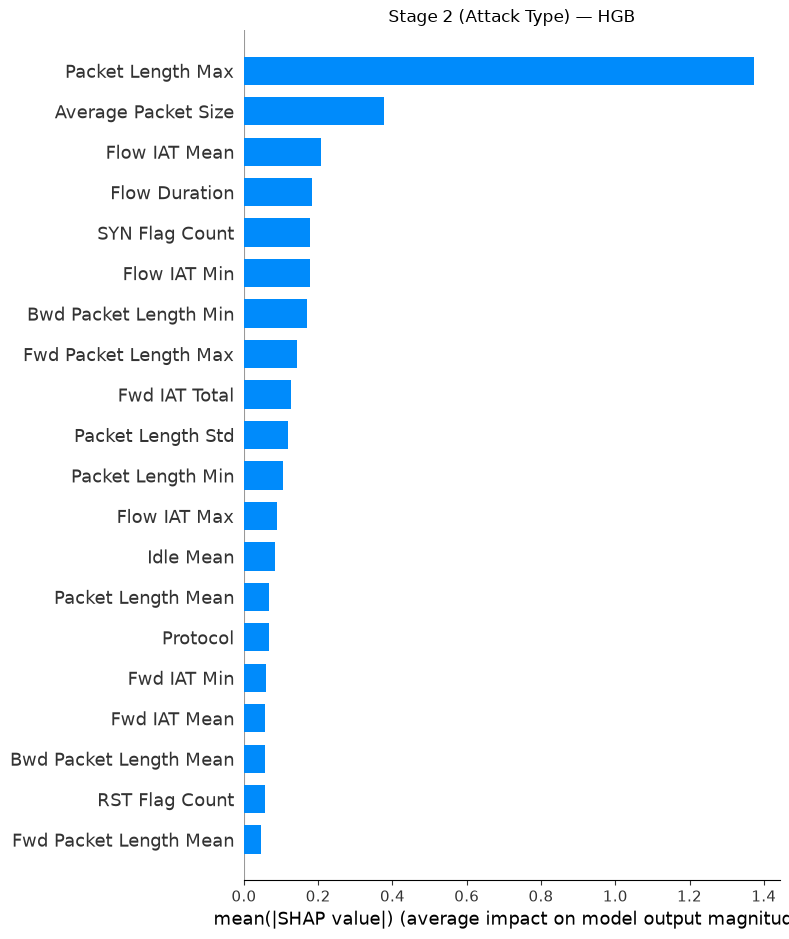

Saved: stage2_HGB_global.png

Stage 2 SHAP — ET (200 rows)...


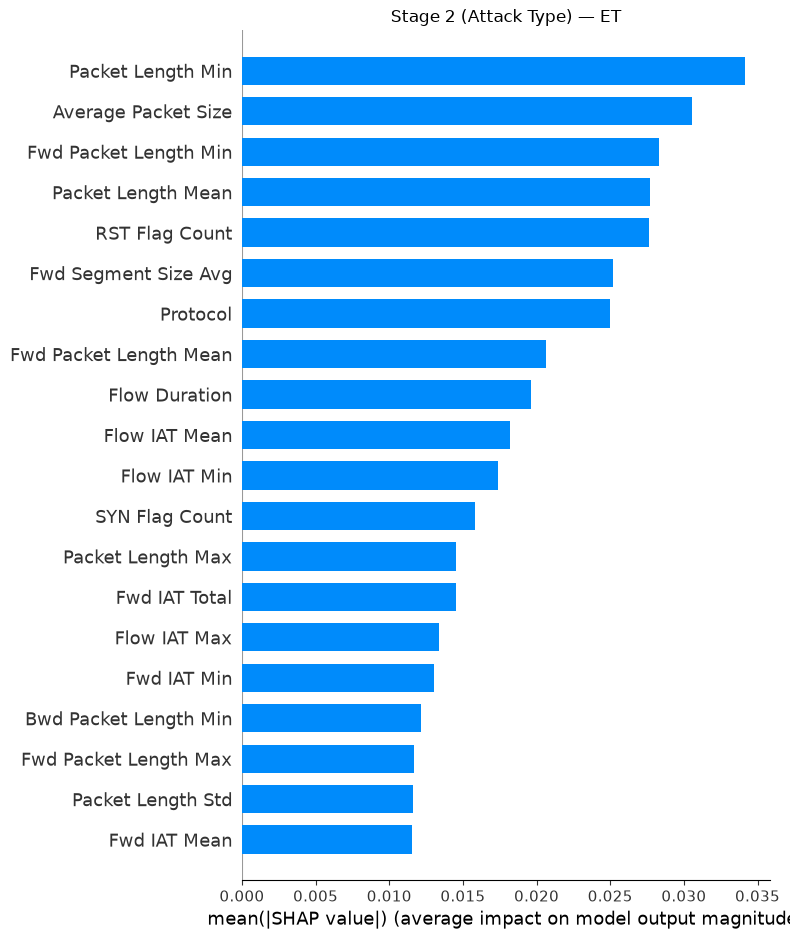

Saved: stage2_ET_global.png

Stage 2 SHAP — RF (200 rows)...


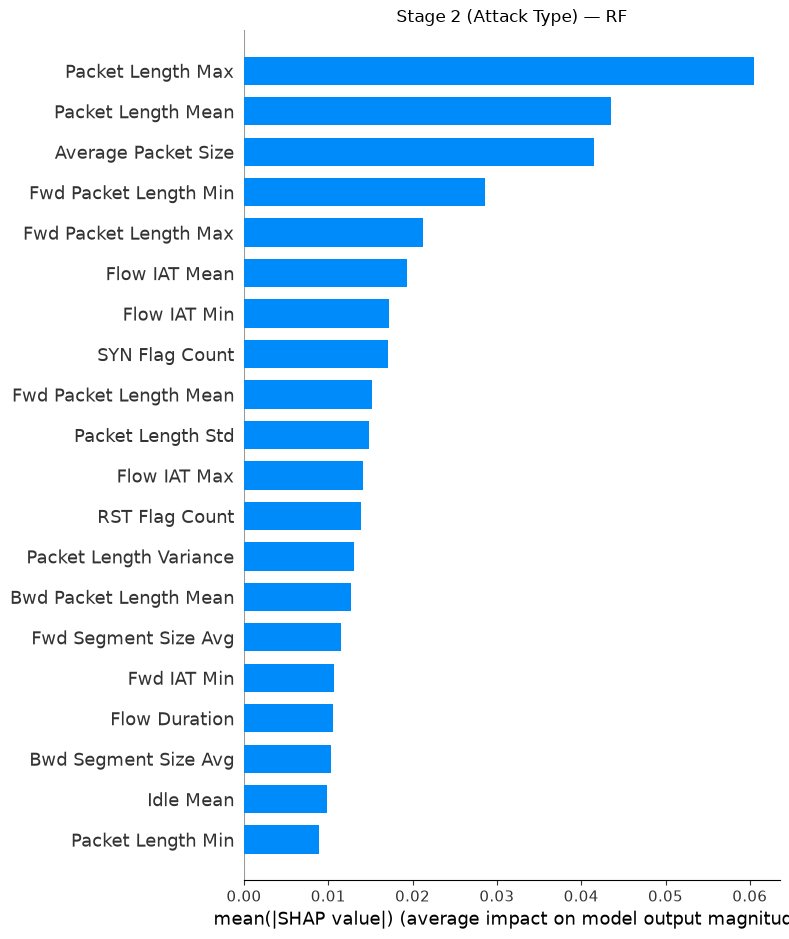

Saved: stage2_RF_global.png

All Stage 2 SHAP done


In [7]:
# Attack-only subsets
X_shap_attacks = X_shap_sample[y_shap_sample != 0]
X_shap_attacks_small = X_shap_small[y_shap_small != 0]

print(f"Stage 2 sample (fast models): {X_shap_attacks.shape}")
print(f"Stage 2 sample (slow models): {X_shap_attacks_small.shape}")

stage2_importance = {}
stage2_sv = {}

# Fast models
for model_name in fast_models:
    print(f"\nStage 2 SHAP — {model_name}...")
    model = joblib.load(f'../results/models/hier_stage2_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_attacks)
    stage2_importance[model_name] = importance
    stage2_sv[model_name] = sv_2d

    plot_shap_bar(
        sv_2d,
        X_shap_attacks,
        f"Stage 2 (Attack Type) — {model_name}",
        f"../results/shap/stage2_{model_name}_global.png"
    )
    print(f"Saved: stage2_{model_name}_global.png")

# Slow models
for model_name in slow_models:
    print(f"\nStage 2 SHAP — {model_name} (200 rows)...")
    model = joblib.load(f'../results/models/hier_stage2_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_attacks_small)
    stage2_importance[model_name] = importance
    stage2_sv[model_name] = sv_2d

    plot_shap_bar(
        sv_2d,
        X_shap_attacks_small,
        f"Stage 2 (Attack Type) — {model_name}",
        f"../results/shap/stage2_{model_name}_global.png"
    )
    print(f"Saved: stage2_{model_name}_global.png")

print("\nAll Stage 2 SHAP done")


Comparison plot — DT...


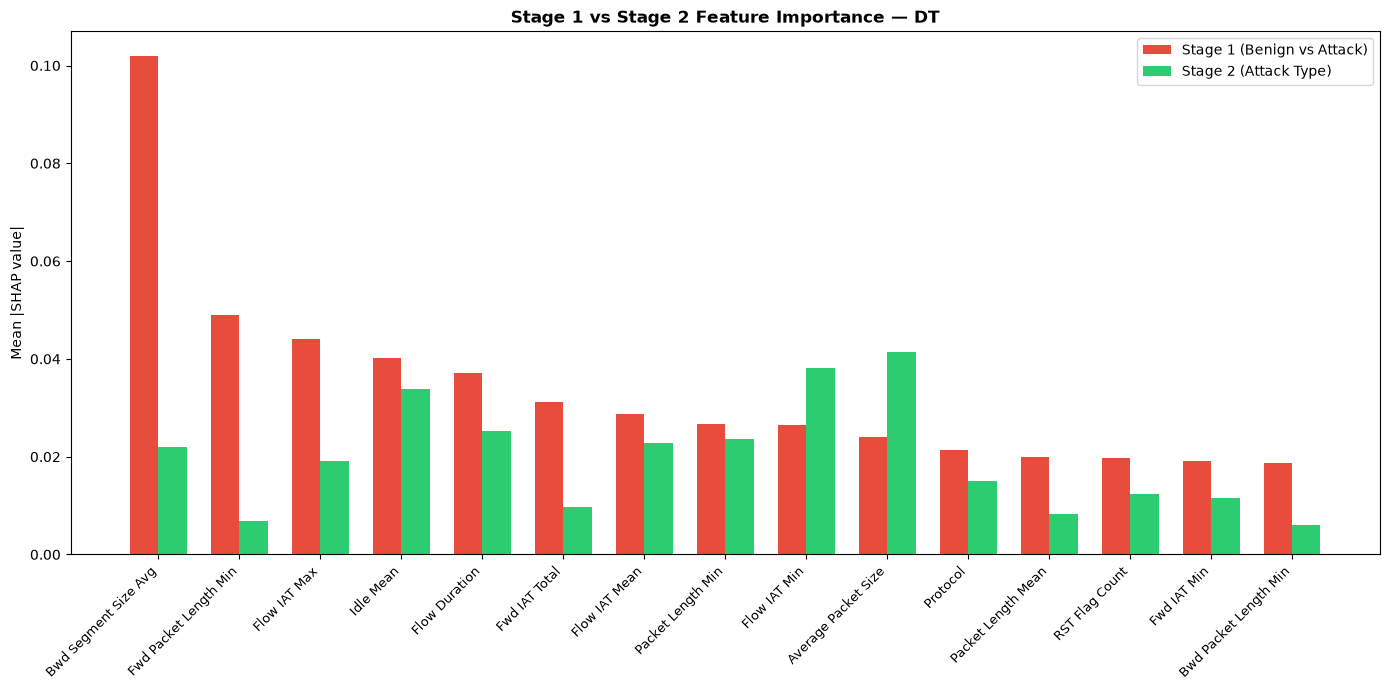

Saved: comparison_DT.png

Comparison plot — XGB...


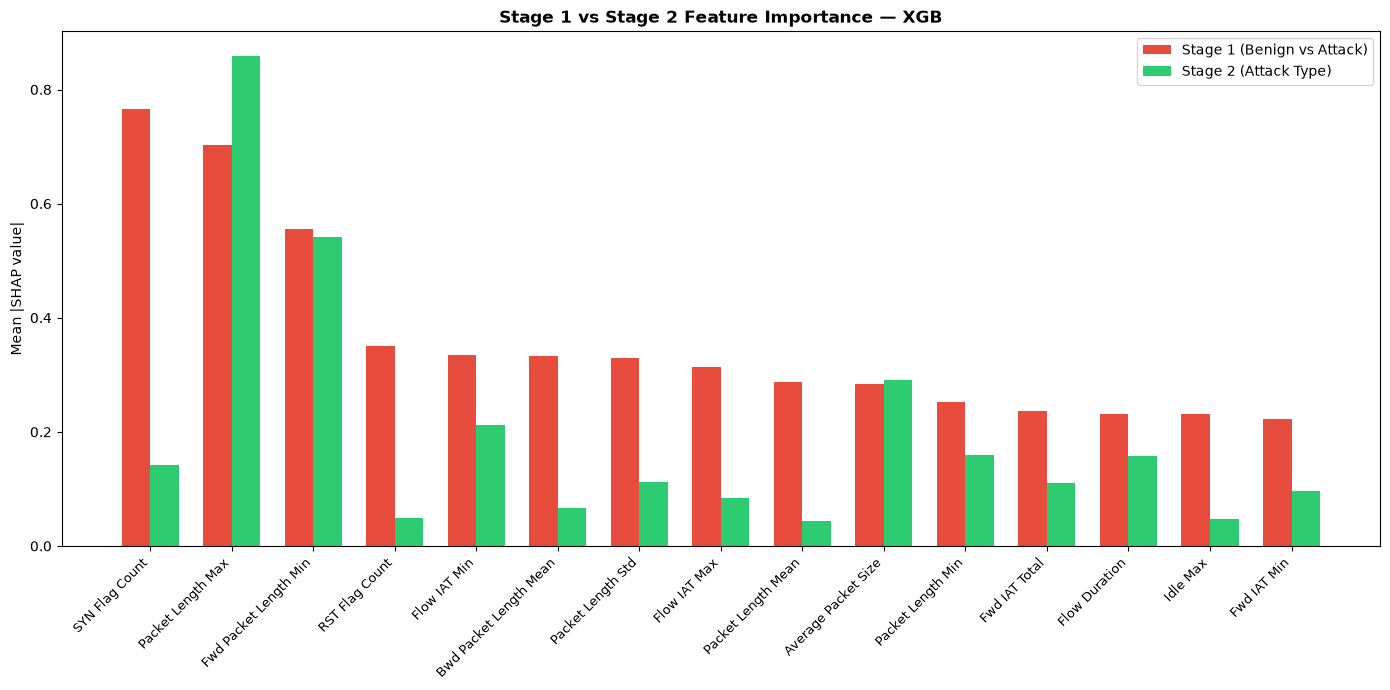

Saved: comparison_XGB.png

Comparison plot — LGBM...


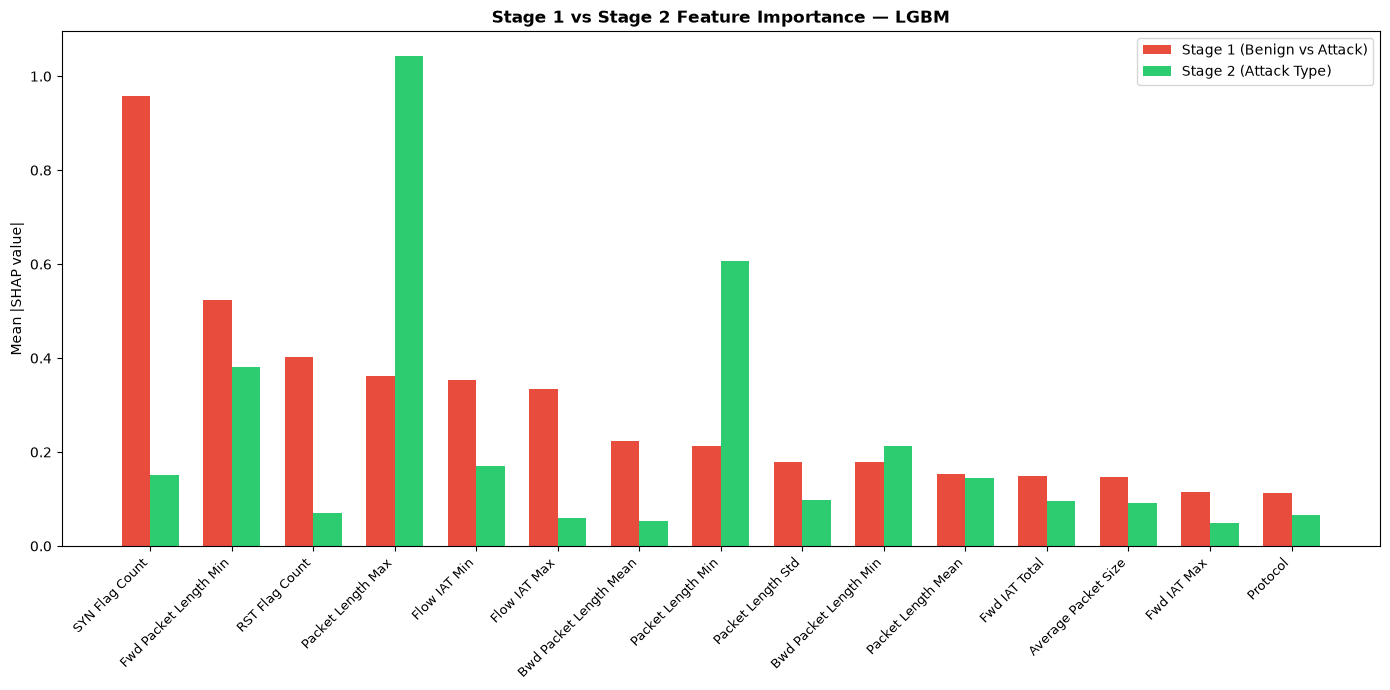

Saved: comparison_LGBM.png

Comparison plot — HGB...


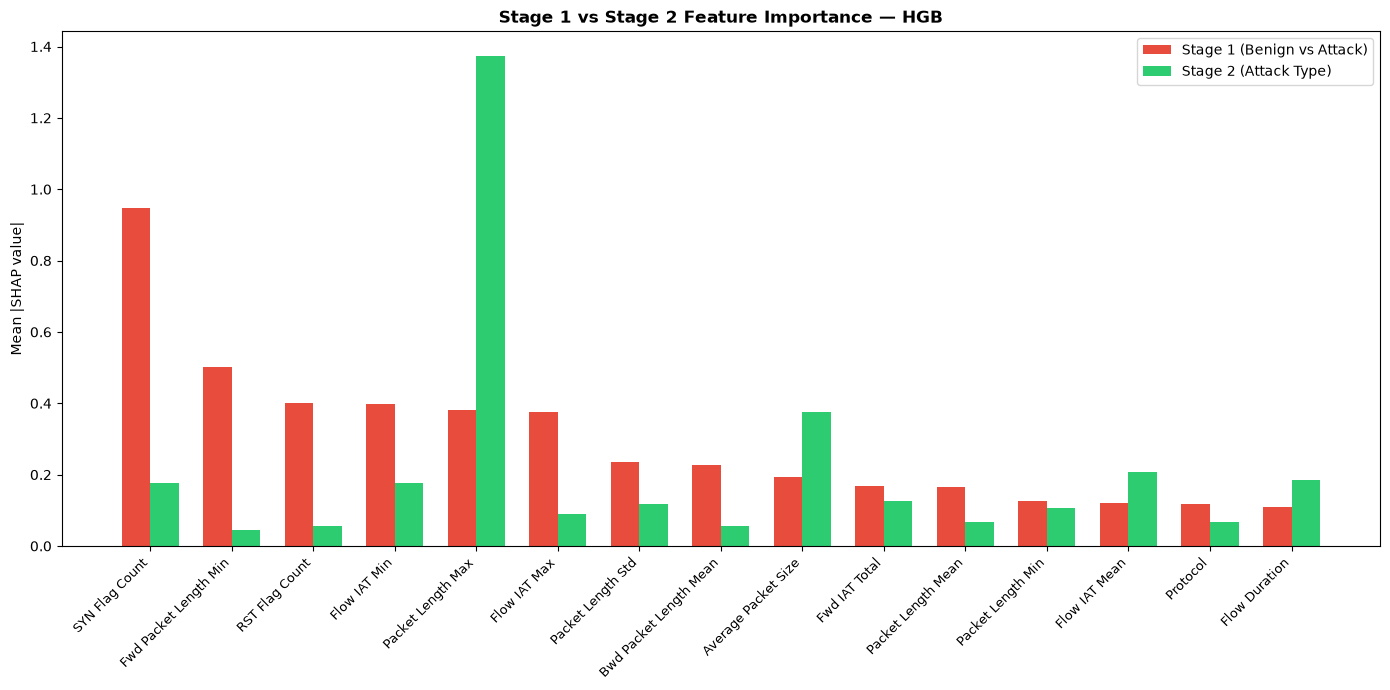

Saved: comparison_HGB.png

Comparison plot — ET...


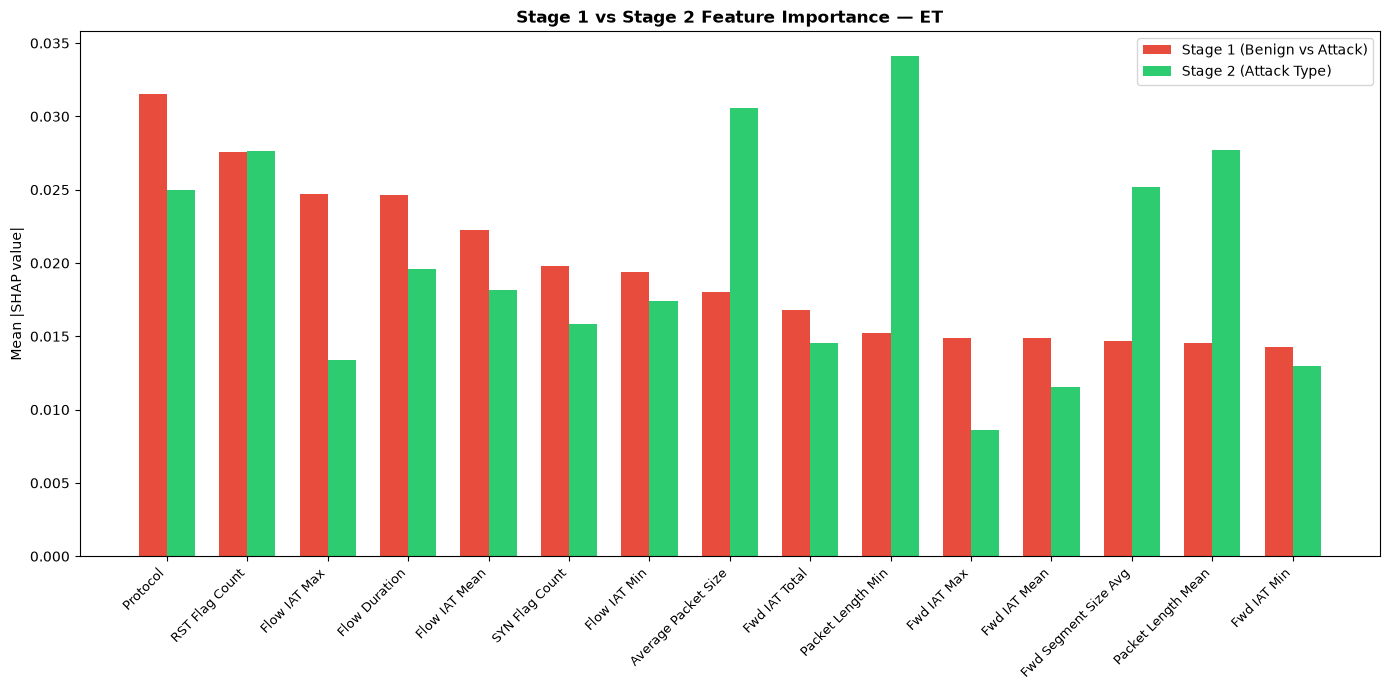

Saved: comparison_ET.png

Comparison plot — RF...


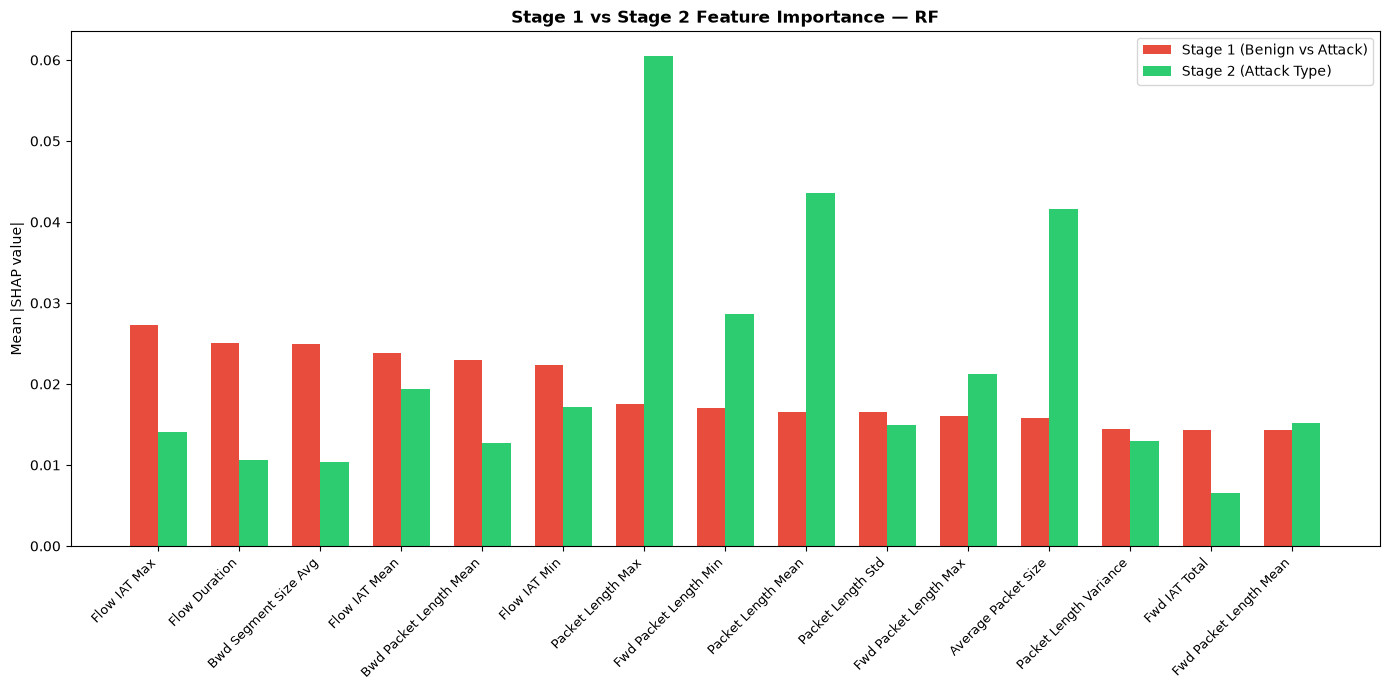

Saved: comparison_RF.png

All comparison plots done


In [8]:
all_models = fast_models + slow_models

for model_name in all_models:
    print(f"\nComparison plot — {model_name}...")
    
    comparison_df = pd.DataFrame({
        'Feature': feature_names,
        'Stage 1 (Binary)': stage1_importance[model_name],
        'Stage 2 (Attack Type)': stage2_importance[model_name],
    }).sort_values('Stage 1 (Binary)', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(comparison_df))
    w = 0.35

    ax.bar(x - w/2, comparison_df['Stage 1 (Binary)'],      w,
           label='Stage 1 (Benign vs Attack)', color='#e74c3c')
    ax.bar(x + w/2, comparison_df['Stage 2 (Attack Type)'], w,
           label='Stage 2 (Attack Type)',      color='#2ecc71')

    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['Feature'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Mean |SHAP value|')
    ax.set_title(f'Stage 1 vs Stage 2 Feature Importance — {model_name}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'../results/shap/comparison_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: comparison_{model_name}.png")

print("\nAll comparison plots done")

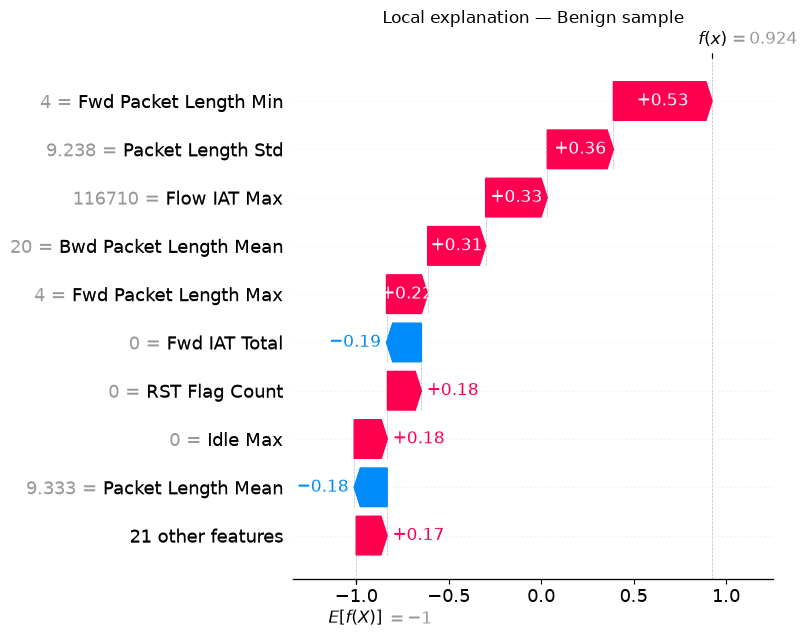

Saved: local_Benign.png


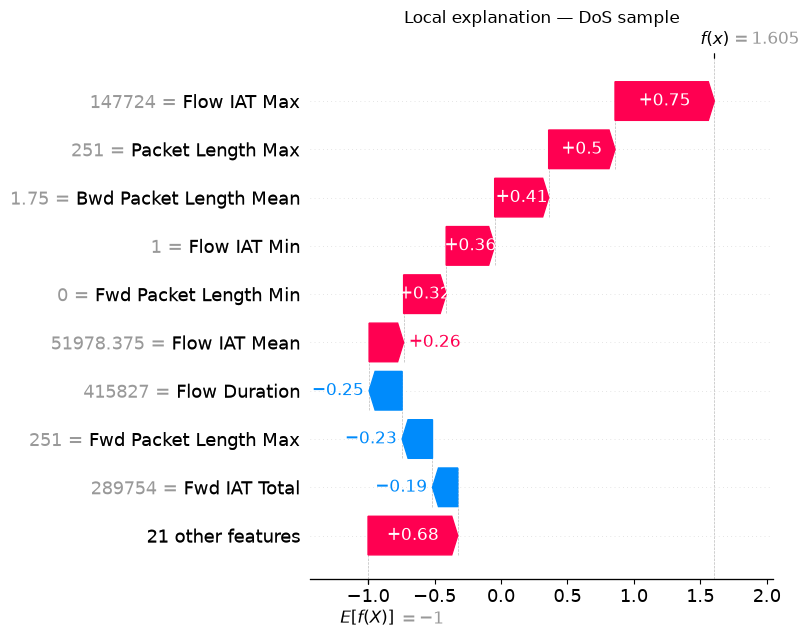

Saved: local_DoS.png


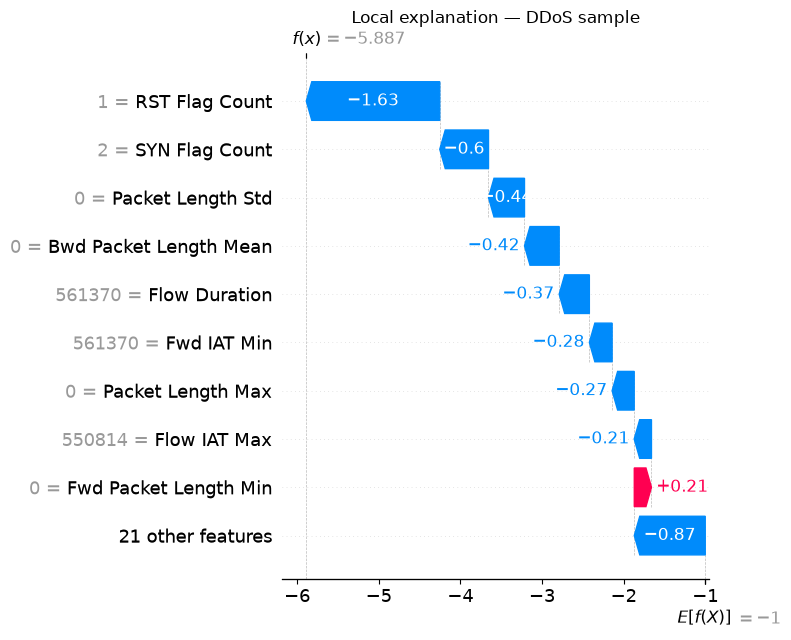

Saved: local_DDoS.png


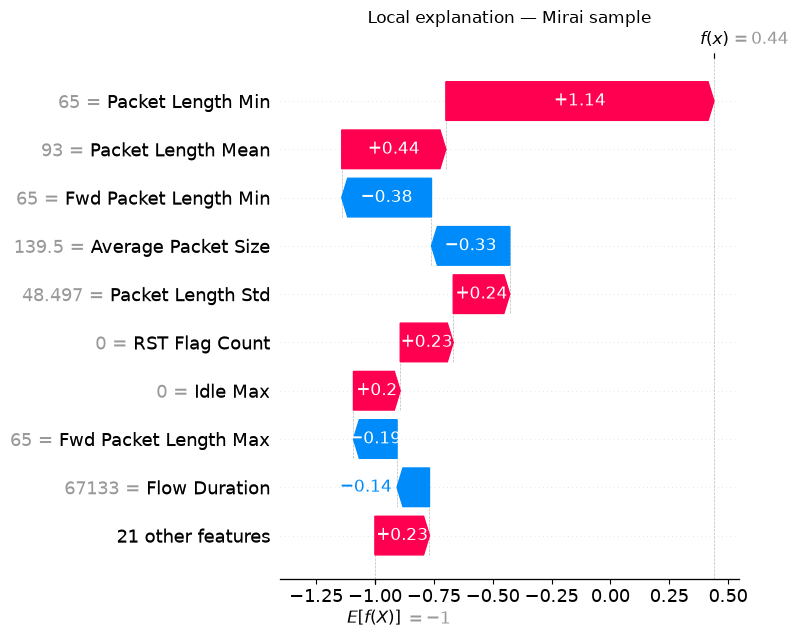

Saved: local_Mirai.png


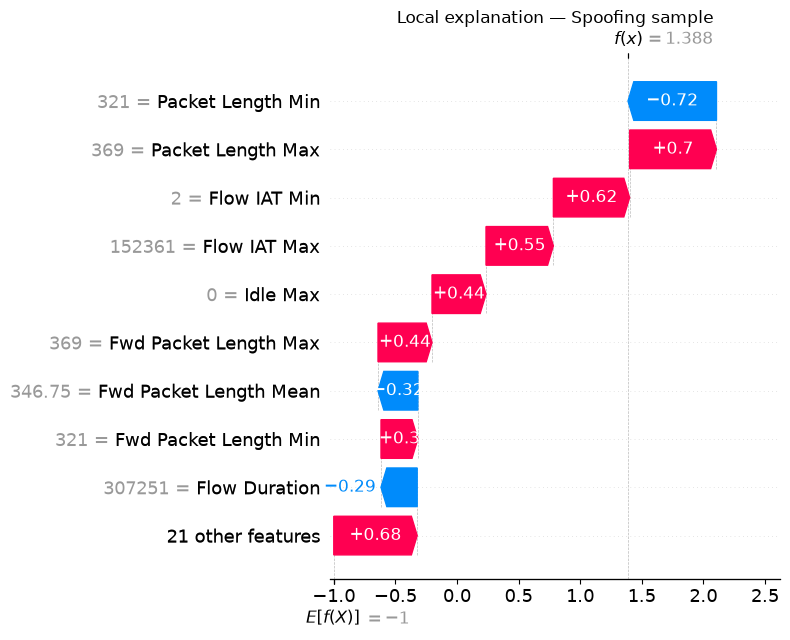

Saved: local_Spoofing.png

All local explanations done


In [9]:
from sklearn.preprocessing import LabelEncoder

model = joblib.load('../results/models/hier_stage1_XGB.pkl')
explainer = shap.TreeExplainer(model)

for class_label, class_name in LABEL_MAP.items():
    # find one test sample from this class
    idx = y_test[y_test == class_label].index[0]
    sample = X_test.loc[[idx]]
    
    sv = explainer.shap_values(sample)
    
    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv_plot = sv[0, :, 0]
        ev = explainer.expected_value[0] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    elif isinstance(sv, list):
        sv_plot = sv[0][0]
        ev = explainer.expected_value[0]
    else:
        sv_plot = sv[0]
        ev = explainer.expected_value

    shap.waterfall_plot(
        shap.Explanation(
            values=sv_plot,
            base_values=ev,
            data=sample.values[0],
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f"Local explanation — {class_name} sample")
    plt.tight_layout()
    plt.savefig(f'../results/shap/local_{class_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: local_{class_name}.png")

print("\nAll local explanations done")